<a href="https://colab.research.google.com/github/Bhanuteja01-kolli/CloudVan_Assesments/blob/main/Zomato_Project_Bangalore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
''' Evaluation Criteria (100 Points)
1. Problem Statement & Basic Metrics (10 Points)'''

import pandas as pd
df = pd.read_csv(
    "/content/zomato.csv",
    engine="python",
    on_bad_lines="skip"
)
# 2)	Total number of restaurants
shape=df.shape[0]
print(shape)
# 3)	Distribution by Delivery vs Dine-out
df['listed_in(type)'].value_counts().head(2)

36832


,count
listed_in(type),
Delivery,19488
Dine-out,12000


In [ ]:
'''2. Data Overview & Quality Check (10 Points)'''
# •	Shape of the dataset (rows & columns)
shape=df.shape
print(shape)
# •	Data types of all columns
dtypes=df.dtypes
print(dtypes)
# •	Conversion of categorical columns to category
cat_cols = ['online_order', 'book_table', 'location', 'listed_in(type)']
df[cat_cols] = df[cat_cols].astype('category')
# •	Missing value detection
miss_det=df.isnull().sum()
print(miss_det)
# •	Statistical summary of numerical columns
stat=df.describe()
print(stat)
df[cat_cols].dtypes



(36832, 17)
url                            object
address                        object
name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
phone                          object
location                       object
rest_type                      object
dish_liked                     object
cuisines                       object
approx_cost(for two people)    object
reviews_list                   object
menu_item                      object
listed_in(type)                object
listed_in(city)                object
dtype: object
url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            5511
votes                              0
phone                            796
location                        

,0
online_order,category
book_table,category
location,category
listed_in(type),category


In [ ]:
''' 3. Non-Graphical Analysis (10 Points)
•	Value counts of:'''
# •	Online ordering
online_orders=df['online_order'].nunique()
print(online_orders)
#  • Table Booking
table_booking=df['book_table'].value_counts()
print(table_booking)
# •	Restaurant types
res_types=df['rest_type'].value_counts()
print(res_types)
#•	Locations
location=df['location'].value_counts()
print(location)
# •	Number of unique cuisines and locations
uni_cusines=df['cuisines'].nunique()
uni_locations=df['location'].nunique()
print(uni_cusines)
print(uni_locations)



2
book_table
No     32566
Yes     4266
Name: count, dtype: int64
rest_type
Quick Bites                   13836
Casual Dining                  7306
Cafe                           2828
Delivery                       2016
Dessert Parlor                 1623
                              ...  
Pop Up                            1
Dessert Parlor, Kiosk             1
Bhojanalya                        1
Casual Dining, Quick Bites        1
Quick Bites, Kiosk                1
Name: count, Length: 90, dtype: int64
location
BTM                      4811
HSR                      2426
Koramangala 5th Block    2374
JP Nagar                 2225
Jayanagar                1890
                         ... 
Hebbal                      2
Rajarajeshwari Nagar        2
Sanjay Nagar                2
KR Puram                    1
Kaggadasapura               1
Name: count, Length: 84, dtype: int64
2365
84


In [ ]:
''' 4. Visual Analysis (After Pre-processing)
Pre-processing Includes:'''
# •	Cleaning rating column (4.2/5 → 4.2)  for cleaning
df['rate']=df['rate'].str.replace('/5','')
df['rate']=df['rate'].str.replace('NEW','0')
df['rate']=df['rate'].str.replace('-','0')
df['rate']=df['rate'].astype(float)

In [ ]:
df


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36827,https://www.zomato.com/bangalore/roots-koraman...,"43/A, 1st Main, Jakkasandra Road, Near Wipro P...",Roots,Yes,Yes,4.6,1895,080 49653573,Koramangala 1st Block,"Casual Dining, Bar","Kadhai Murgh, Coffee Toffee, Pasta, Tandoori C...","North Indian, South Indian, Chinese, Continent...","1,200","[('Rated 4.0', 'RATED\n Loved the place and a...",[],Dine-out,Koramangala 7th Block
36828,https://www.zomato.com/bangalore/3bs-buddies-b...,"5th Floor, CPR Tower, 100 Feet Ring Road, 1st ...","3B's - Buddies, Bar & Barbecues",No,Yes,4.4,1178,+91 8880088696,BTM,"Casual Dining, Bar","Paan Ice Cream, Cocktails, Fish Grill, Crispy ...","North Indian, Mediterranean, European, BBQ","1,100","[('Rated 1.0', 'RATED\n Worst buffet dinner I...",[],Dine-out,Koramangala 7th Block
36829,https://www.zomato.com/bangalore/pin-me-down-b...,"29, Tavakere Main Road, Behind Forum Mall, Kor...",Pin Me Down,Yes,Yes,4.5,823,+91 8861568945\n+91 8178831745,BTM,Casual Dining,"Paneer Tikka, Chilli Chicken, Pizza, Mocktails...","Continental, Mexican, Chinese, North Indian",800,"[('Rated 5.0', ""RATED\n One of the coolest ro...",[],Dine-out,Koramangala 7th Block
36830,https://www.zomato.com/bangalore/bistro-clayto...,"11, 80 Feet Road, Next to SBI, Koramangala 1st...",Bistro Claytopia,Yes,Yes,4.1,1856,080 43759392\n+91 9834934359,Koramangala 1st Block,Cafe,"Burgers, Coffee, Cappuccino, Barbeque Burger, ...","Cafe, American, Italian, Burger",600,"[('Rated 4.0', ''), ('Rated 4.0', ''), ('Rated...",[],Dine-out,Koramangala 7th Block


In [ ]:
df.dtypes

,0
url,object
address,object
name,object
online_order,category
book_table,category
rate,float64
votes,int64
phone,object
location,category
rest_type,object


In [ ]:
# •	Converting cost column to numeric
df['approx_cost(for two people)']=df['approx_cost(for two people)'].str.replace(',','')
df['approx_cost(for two people)']=df['approx_cost(for two people)'].astype(float)

In [ ]:
df.dtypes

,0
url,object
address,object
name,object
online_order,category
book_table,category
rate,float64
votes,int64
phone,object
location,category
rest_type,object


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
'''•	Unnesting columns: '''
# •	cuisines

df['cusines']=df['cuisines'].str.split(',')

df_explode=df.explode('cuisines')


In [ ]:
df


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),cusines
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,"[North Indian, Mughlai, Chinese]"
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari,"[Chinese, North Indian, Thai]"
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari,"[Cafe, Mexican, Italian]"
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari,"[South Indian, North Indian]"
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari,"[North Indian, Rajasthani]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3754,https://www.zomato.com/bangalore/monsoon-bella...,"The Bay, Campus 8A, RMZ Ecoworld, Bellandur, B...",Monsoon,No,No,2.8,11,+91 9885576726,Bellandur,Food Court,NaN,Continental,1000.0,"[('Rated 3.0', 'RATED\n This place serves som...",[],Buffet,Bellandur,[Continental]
3755,https://www.zomato.com/bangalore/biso-citrus-h...,"Citrus Hotels, 80/2, Marthalli, Sarjapur Outer...",BISO - Citrus Hotels,No,No,3.0,120,+91 7760995522\r\n+91 7760338899,Bellandur,Casual Dining,"Salads, Gulab Jamun, Pasta, Fish, Rasgulla, Co...","North Indian, Italian, Chinese, Asian",1000.0,"[('Rated 3.0', ""RATED\n I've been here for lu...",[],Buffet,Bellandur,"[North Indian, Italian, Chinese, Asian]"
3756,https://www.zomato.com/bangalore/chefs-gallery...,"1st Floor, RMZ Ecospace, Outer Ring Road, Bell...",Chef's Gallery,No,No,3.5,95,+91 9972432211,Bellandur,Casual Dining,"Pasta, Lunch Buffet, Pizza, Noodles, Draught Beer","Chinese, Italian, North Indian",700.0,"[('Rated 4.5', 'RATED\n Was a very nice exper...",[],Buffet,Bellandur,"[Chinese, Italian, North Indian]"
3757,https://www.zomato.com/bangalore/palkis-bellan...,"2, Outer Ring Road",Palki's,No,No,3.0,155,080 25747067\r\n+91 7760349362,Bellandur,Casual Dining,"Outdoor Sitting Arrangement, Vegetable Biryani...","North Indian, Biryani",800.0,"[('Rated 3.0', 'RATED\n Ordered a lot of veg ...",[],Buffet,Bellandur,"[North Indian, Biryani]"


In [ ]:
# •	location
df['location']=df['location'].astype(str)
df['location']=df['location'].str.split(',')

df_explode_loc=df.explode('location')

In [ ]:
df

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),cusines
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,080 42297555\r\n+91 9743772233,[Banashankari],Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,"[North Indian, Mughlai, Chinese]"
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,080 41714161,[Banashankari],Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari,"[Chinese, North Indian, Thai]"
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,+91 9663487993,[Banashankari],"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari,"[Cafe, Mexican, Italian]"
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,[Banashankari],Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari,"[South Indian, North Indian]"
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,+91 8026612447\r\n+91 9901210005,[Basavanagudi],Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari,"[North Indian, Rajasthani]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3754,https://www.zomato.com/bangalore/monsoon-bella...,"The Bay, Campus 8A, RMZ Ecoworld, Bellandur, B...",Monsoon,No,No,2.8,11,+91 9885576726,[Bellandur],Food Court,NaN,Continental,1000.0,"[('Rated 3.0', 'RATED\n This place serves som...",[],Buffet,Bellandur,[Continental]
3755,https://www.zomato.com/bangalore/biso-citrus-h...,"Citrus Hotels, 80/2, Marthalli, Sarjapur Outer...",BISO - Citrus Hotels,No,No,3.0,120,+91 7760995522\r\n+91 7760338899,[Bellandur],Casual Dining,"Salads, Gulab Jamun, Pasta, Fish, Rasgulla, Co...","North Indian, Italian, Chinese, Asian",1000.0,"[('Rated 3.0', ""RATED\n I've been here for lu...",[],Buffet,Bellandur,"[North Indian, Italian, Chinese, Asian]"
3756,https://www.zomato.com/bangalore/chefs-gallery...,"1st Floor, RMZ Ecospace, Outer Ring Road, Bell...",Chef's Gallery,No,No,3.5,95,+91 9972432211,[Bellandur],Casual Dining,"Pasta, Lunch Buffet, Pizza, Noodles, Draught Beer","Chinese, Italian, North Indian",700.0,"[('Rated 4.5', 'RATED\n Was a very nice exper...",[],Buffet,Bellandur,"[Chinese, Italian, North Indian]"
3757,https://www.zomato.com/bangalore/palkis-bellan...,"2, Outer Ring Road",Palki's,No,No,3.0,155,080 25747067\r\n+91 7760349362,[Bellandur],Casual Dining,"Outdoor Sitting Arrangement, Vegetable Biryani...","North Indian, Biryani",800.0,"[('Rated 3.0', 'RATED\n Ordered a lot of veg ...",[],Buffet,Bellandur,"[North Indian, Biryani]"


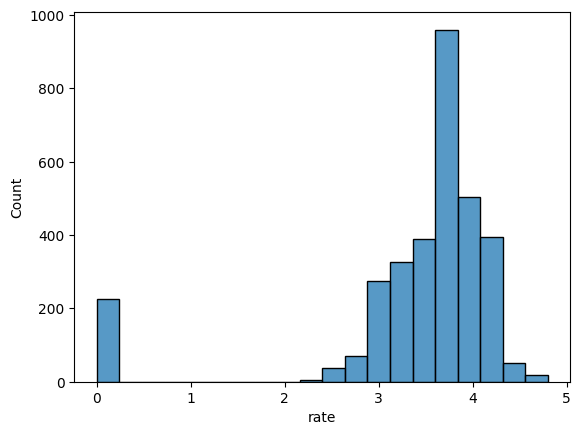

In [ ]:
'''4.1 Univariate Analysis – Continuous Variables
 Pre-processing Includes:
 •	Histogram / Distplot for:'''
import seaborn as sns
import matplotlib.pyplot as plt

# •	Ratings
sns.histplot(df['rate'],bins=20)
plt.show()





<Axes: xlabel='approx_cost(for two people)', ylabel='Count'>

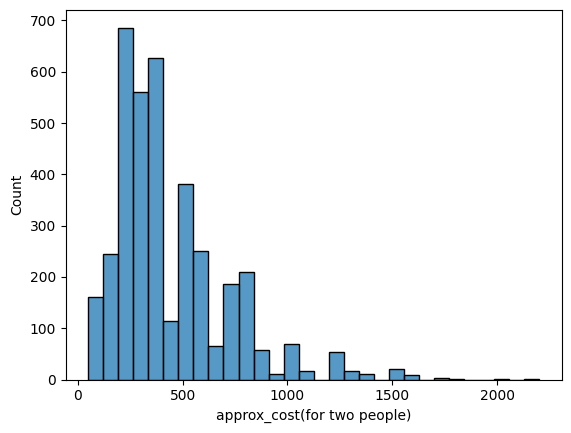

In [ ]:
# •	Cost for two
sns.histplot(df['approx_cost(for two people)'],bins=30)

<Axes: xlabel='votes', ylabel='Count'>

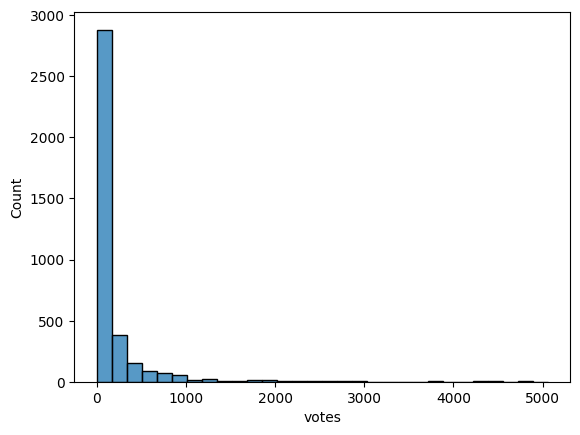

In [ ]:
#votes
sns.histplot(df['votes'],bins=30)

<Axes: xlabel='online_order', ylabel='rate'>

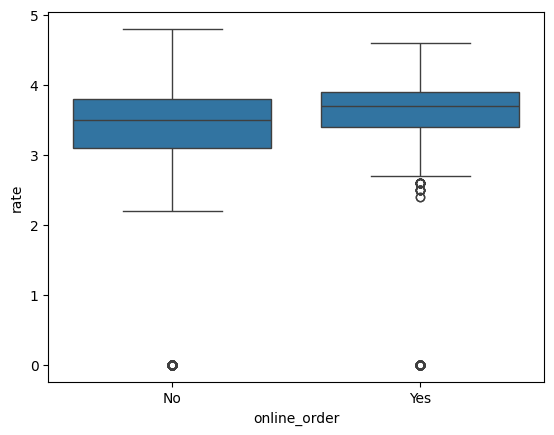

In [ ]:
'''4.2 Bivariate Analysis – Categorical vs Continuous (10 Points)
•	Boxplots:'''
# •	Rating vs Online Order
sns.boxplot(x='online_order',y='rate',data=df)


In [ ]:
# •	Rating vs Table Booking
sns.boxplot(y='rate',x='book_table',data=df)


NameError: name 'sns' is not defined

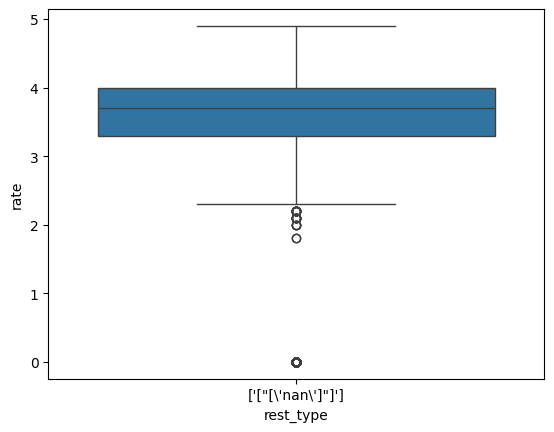

In [ ]:
from numpy import result_type
# •	Rating vs Restaurant Type
df['rest_type'] = df['rest_type'].astype(str)
df['rest_type'] = df['rest_type'].str.split(',')
df_rt = df.explode('rest_type')
df_rt['rest_type'] = df_rt['rest_type'].str.strip()

top_rest_types = df_rt['rest_type'].value_counts().head(10).index
df_rt = df_rt[df_rt['rest_type'].isin(top_rest_types)]
sns.boxplot(x='rest_type',y='rate',data=df_rt)
plt.show()

# •	Rating vs Top Locations

<Axes: xlabel='location', ylabel='rate'>

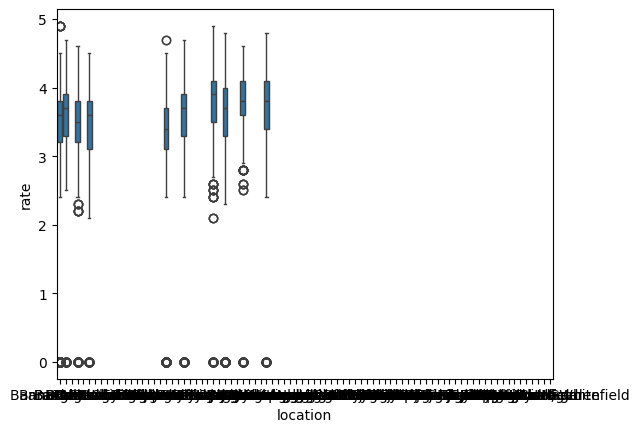

In [ ]:
# •	Rating vs Top Locations
top_locations = df['location'].value_counts().head(10).index
sns.boxplot(x='location', y='rate', data=df[df['location'].isin(top_locations)])

In [ ]:
''' 5. Missing Value & Outlier Analysis (10 Points)
•	Identification of missing values in:'''
# •	Rating
# •	Cuisines
# •	Restaurant type

df[['rate','cuisines','rest_type']].isnull().sum()


,0
rate,3945
cuisines,19
rest_type,0


<Axes: xlabel='approx_cost(for two people)'>

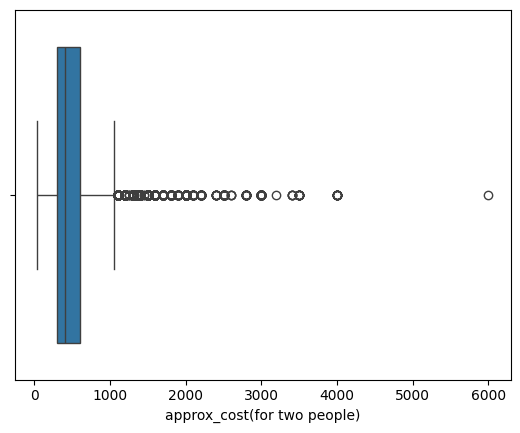

In [ ]:
''' •	Outlier detection in:'''
# •	Cost
sns.boxplot(x=df['approx_cost(for two people)'])


<Axes: xlabel='votes'>

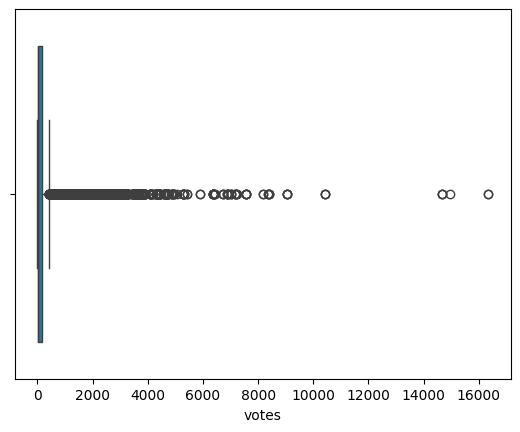

In [ ]:
# •	Votes
sns.boxplot(x=df['votes'])